# Анализ аудиомоделей / Audio Models Analysis

Ноутбук загружает обученные аудиомодели классификации эмоций речи и оценивает их
на тестовом наборе данных **Dusha** (`combine_balanced_test.lmdb`).

Для каждой модели выводятся:
- Сводные метрики (Accuracy, Balanced Accuracy, F1, MCC, ROC-AUC)
- Отчёт по классам (Precision / Recall / F1)
- Матрица ошибок (confusion matrix)

**Эмоции (4 класса):** `angry` · `sad` · `neutral` · `positive`

 

---
## Содержание

| # | Модель | Описание |
|---|--------|----------|
| 1 | [Logistic Regression](#1-logistic-regression) | MFCC + sklearn LogReg (baseline) |
| 2 | [SVM](#2-svm) | MFCC + SVM (RBF kernel) |
| 3 | [Random Forest](#3-random-forest) | MFCC + ансамбль решающих деревьев |
| 4 | [OpenSmile XGBoost](#4-opensmile-xgboost) | OpenSMILE eGeMAPS + XGBoost/LightGBM |
| 5 | [CNN](#5-cnn) | Спектрограмма + свёрточная нейросеть |
| 6 | [CNN + BiLSTM](#6-cnn--bilstm) | Спектрограмма + CNN + рекуррентная сеть |
| 7 | [Wav2Vec2 XLSR-300M](#7-wav2vec2-xlsr-300m--self-attention) | Raw waveform + предобученный трансформер |

In [1]:
import sys
from pathlib import Path

def _find_repo_root():
    cwd = Path.cwd().resolve()
    for p in [cwd] + list(cwd.parents):
        if (p / 'dusha' / 'my_experiments').is_dir():
            return p
    return None

_REPO_ROOT = _find_repo_root()
if _REPO_ROOT is not None and str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from dusha.my_experiments.utils.config_utils import (
    PROJECT_ROOT, DATASET_PATH, TARGET_NAMES,
)

import numpy as np
import torch
import warnings
warnings.filterwarnings('ignore')

AGGREGATED_DIR = DATASET_PATH / 'processed_dataset_090' / 'aggregated_dataset'

# ──────────────────────────────────────────────────────
# ВЫБОР ТЕСТОВОГО НАБОРА ДАННЫХ
# Раскомментируйте нужный путь:
# ──────────────────────────────────────────────────────
# TEST_LMDB = AGGREGATED_DIR / 'combine_balanced_test.lmdb'        # полный сбалансированный тест
# TEST_LMDB = AGGREGATED_DIR / 'combine_balanced_test_small.lmdb'  # малая версия
TEST_LMDB = AGGREGATED_DIR / 'dusha_resd_test.lmdb'             # Dusha + RESD

CHECKPOINTS_DIR = PROJECT_ROOT / 'my_experiments' / 'checkpoints' / 'audio'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Test dataset: {TEST_LMDB}')
print(f'Exists: {TEST_LMDB.exists()}')
print(f'Device: {DEVICE}')
print(f'Checkpoints: {CHECKPOINTS_DIR}')

Test dataset: /home/natlis/PycharmProjects/dusha_new/dusha/data_processing/dataset/processed_dataset_090/aggregated_dataset/dusha_resd_test.lmdb
Exists: True
Device: cpu
Checkpoints: /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio


---
## Вспомогательные функции

In [2]:
import pickle
import lmdb

from dusha.my_experiments.utils.lmdb_utils import open_lmdb_readonly, get_lmdb_length, parse_label_to_index
from dusha.my_experiments.utils.model_io import load_sklearn_model, load_pytorch_model
from dusha.my_experiments.utils.metrics import print_eval_block, compute_classification_metrics


def _to_fixed_vector(feat: np.ndarray) -> np.ndarray:
    arr = np.asarray(feat)
    if arr.ndim == 1:
        return arr.astype(np.float32)
    mean_part = arr.mean(axis=-1).reshape(-1)
    std_part = arr.std(axis=-1).reshape(-1)
    return np.concatenate([mean_part, std_part]).astype(np.float32)


def load_features_for_sklearn(lmdb_path):
    from dusha.my_experiments.utils.lmdb_utils import load_feature_vectors_from_lmdb
    return load_feature_vectors_from_lmdb(
        lmdb_path=Path(lmdb_path),
        vectorize_fn=_to_fixed_vector,
        label_kind='emotion',
    )


def evaluate_sklearn(model, scaler, X_test, y_test):
    X_test_scaled = scaler.transform(X_test)
    y_pred = model.predict(X_test_scaled)
    
    has_proba = hasattr(model, 'predict_proba')
    probs = model.predict_proba(X_test_scaled) if has_proba else None
    
    y_true_num = np.array([parse_label_to_index(l) for l in y_test])
    y_pred_num = np.array([parse_label_to_index(l) for l in y_pred])
    
    metrics = compute_classification_metrics(y_true_num, y_pred_num, probs)
    return metrics, y_true_num, y_pred_num

---
## 1. Logistic Regression

**Тип:** Базовый sklearn-классификатор  
**Признаки:** MFCC (mean+std per frame)  
**Чекпоинт:** `logictic_regressoin_combine_balanced_train_small_model.pkl`

✓ Модель загружена из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/logistic_regression_combine_balanced_train_model.pkl
✓ Scaler загружен из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/logistic_regression_combine_balanced_train_scaler.pkl

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Logistic Regression - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Accuracy,0.4739
1,Balanced Accuracy,0.4650
2,Precision (macro),0.4678
3,Recall (macro),0.4650
4,F1 (macro),0.4657
5,F1 (weighted),0.4708
6,MCC,0.2836
7,ROC-AUC (OvR macro),0.5008


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.4741,0.4390,0.4559,1378
1,sad,0.5332,0.5951,0.5625,2213
2,neutral,0.3545,0.3295,0.3415,1730
3,positive,0.5095,0.4965,0.5029,1295


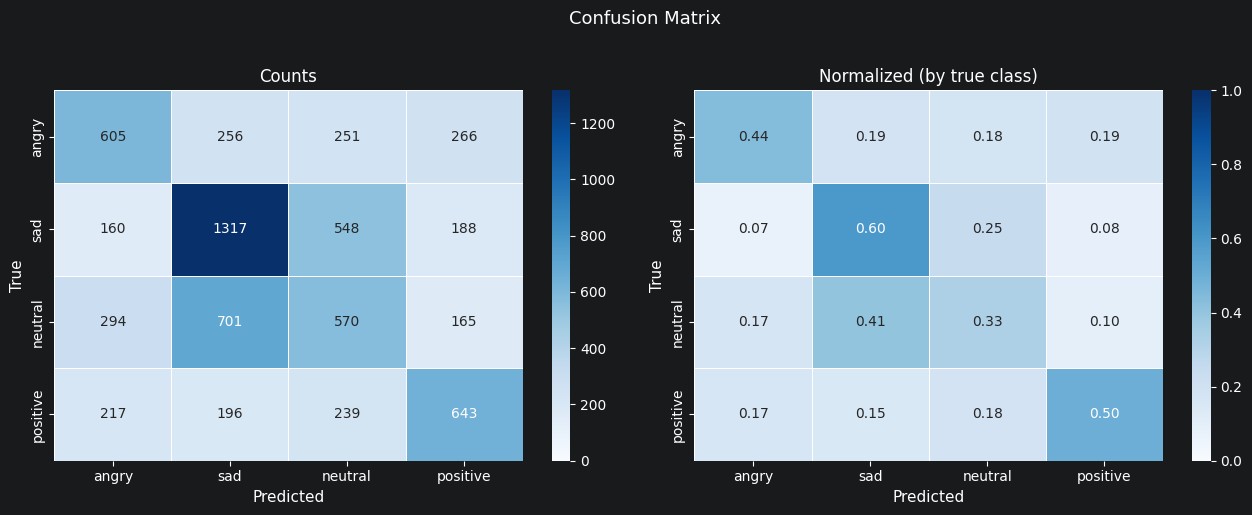

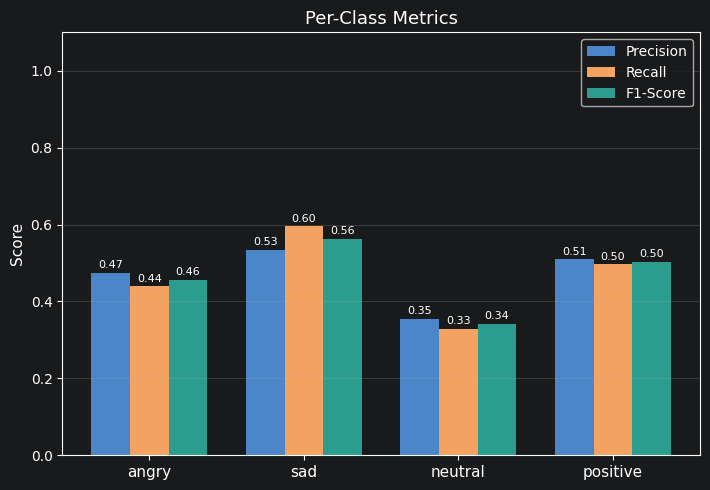

In [7]:
dataset_name = 'combine_balanced_train'
model_lr, scaler_lr = load_sklearn_model(
    dataset_name, models_dir=CHECKPOINTS_DIR, model_name='logistic_regression'
)
X_test_lr, y_test_lr = load_features_for_sklearn(TEST_LMDB)
metrics_lr, yt_lr, yp_lr = evaluate_sklearn(model_lr, scaler_lr, X_test_lr, y_test_lr)
print_eval_block('Logistic Regression - Test Metrics', metrics_lr, yt_lr, yp_lr)

---
## 2. SVM

**Тип:** Support Vector Machine (RBF kernel)  
**Признаки:** MFCC (mean+std per frame)  
**Чекпоинт:** `svm_combine_balanced_train_model.pkl`

✓ Модель загружена из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/svm_combine_balanced_train_model.pkl
✓ Scaler загружен из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/svm_combine_balanced_train_scaler.pkl

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SVM - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Accuracy,0.5048
1,Balanced Accuracy,0.4902
2,Precision (macro),0.5008
3,Recall (macro),0.4902
4,F1 (macro),0.4940
5,F1 (weighted),0.5027
6,MCC,0.3245
7,ROC-AUC (OvR macro),N/A


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.5075,0.4405,0.4716,1378
1,sad,0.5819,0.6521,0.6150,2213
2,neutral,0.3706,0.3809,0.3757,1730
3,positive,0.5430,0.4873,0.5136,1295


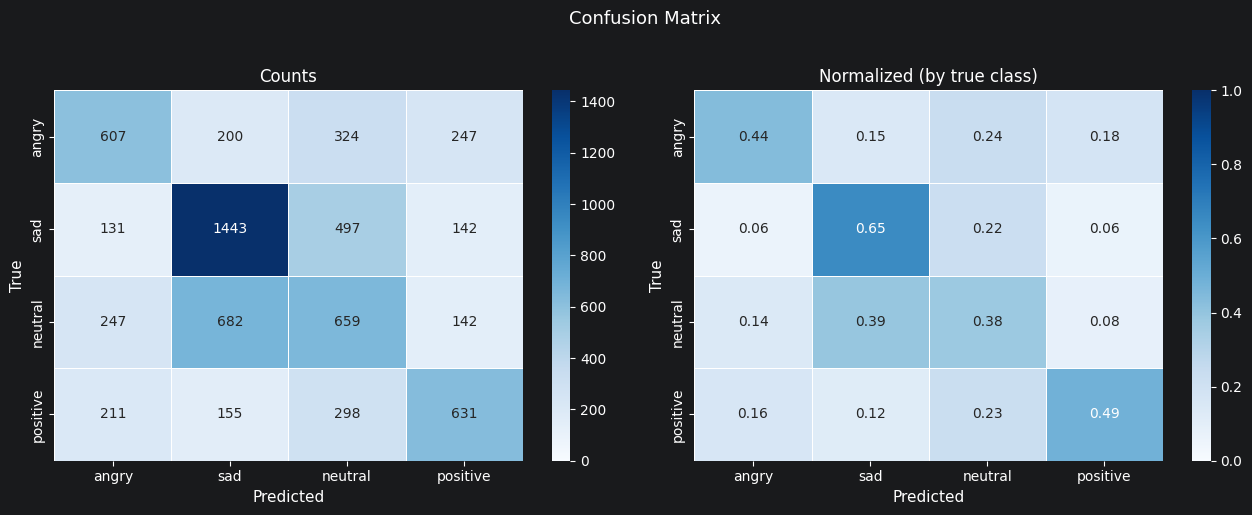

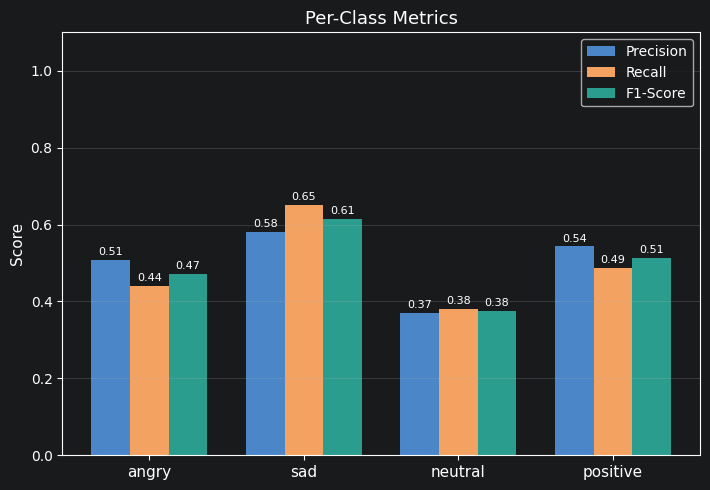

In [8]:
dataset_name = 'combine_balanced_train'
model_svm, scaler_svm = load_sklearn_model(
    dataset_name, models_dir=CHECKPOINTS_DIR, model_name='svm'
)
X_test_svm, y_test_svm = load_features_for_sklearn(TEST_LMDB)
metrics_svm, yt_svm, yp_svm = evaluate_sklearn(model_svm, scaler_svm, X_test_svm, y_test_svm)
print_eval_block('SVM - Test Metrics', metrics_svm, yt_svm, yp_svm)

---
## 3. Random Forest

**Тип:** Ансамбль решающих деревьев  
**Признаки:** MFCC (mean+std per frame)  
**Чекпоинт:** `random_forest_combine_balanced_train_model.pkl`

✓ Модель загружена из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/random_forest_combine_balanced_train_model.pkl
✓ Scaler загружен из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/random_forest_combine_balanced_train_scaler.pkl

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Random Forest - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.0s finished


,Metric,Value
0,Accuracy,0.4696
1,Balanced Accuracy,0.4525
2,Precision (macro),0.4636
3,Recall (macro),0.4525
4,F1 (macro),0.4561
5,F1 (weighted),0.4665
6,MCC,0.2753
7,ROC-AUC (OvR macro),0.5007


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.4669,0.4042,0.4333,1378
1,sad,0.5470,0.6286,0.5849,2213
2,neutral,0.3424,0.3503,0.3463,1730
3,positive,0.4982,0.4270,0.4599,1295


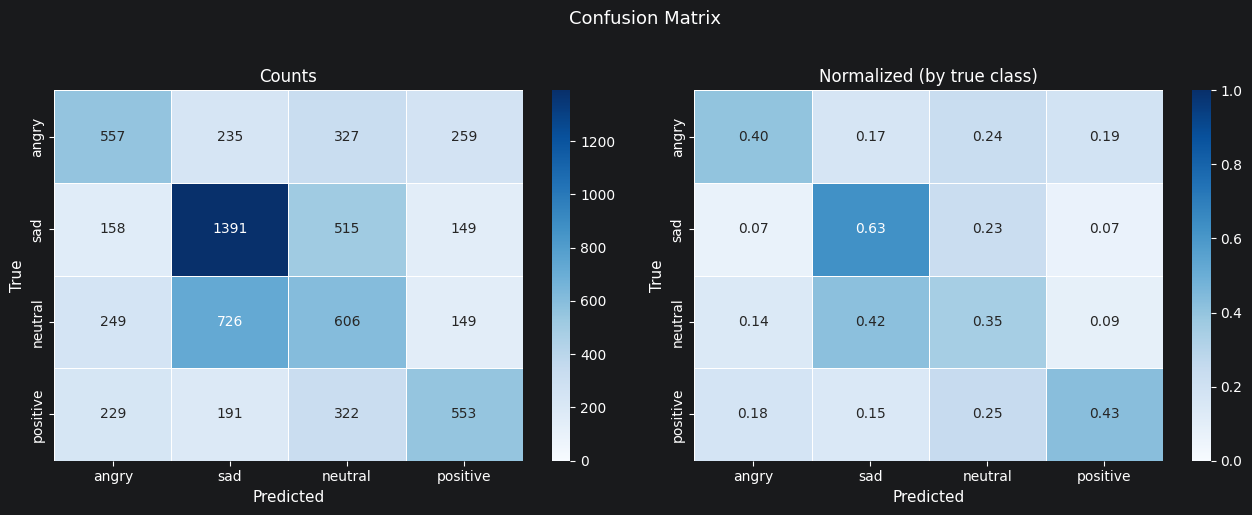

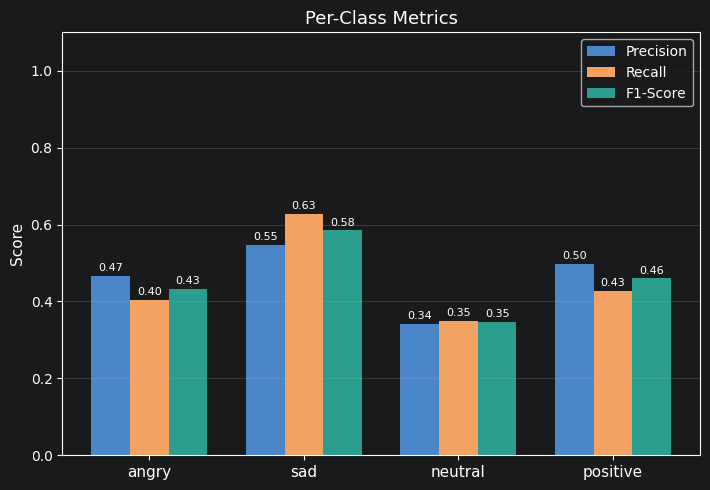

In [9]:
dataset_name = 'combine_balanced_train'
model_rf, scaler_rf = load_sklearn_model(
    dataset_name, models_dir=CHECKPOINTS_DIR, model_name='random_forest'
)
X_test_rf, y_test_rf = load_features_for_sklearn(TEST_LMDB)
metrics_rf, yt_rf, yp_rf = evaluate_sklearn(model_rf, scaler_rf, X_test_rf, y_test_rf)
print_eval_block('Random Forest - Test Metrics', metrics_rf, yt_rf, yp_rf)

---
## 4. OpenSmile XGBoost

**Тип:** Градиентный бустинг (XGBoost/LightGBM)  
**Признаки:** OpenSMILE eGeMAPS (88 признаков), извлекаются из WAV-файлов  
**Чекпоинт:** `openSmile_XGBoost_combine_balanced_train_model.pkl`  
**Примечание:** Требует OpenSMIME и доступ к исходным WAV-файлам.

XGBoost model loaded: /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/openSmile_XGBoost_combine_balanced_train_model.pkl
Model type: XGBClassifier

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  OpenSmile XGBoost - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Accuracy,0.4937
1,Balanced Accuracy,0.4805
2,Precision (macro),0.4850
3,Recall (macro),0.4805
4,F1 (macro),0.4814
5,F1 (weighted),0.4899
6,MCC,0.3100
7,ROC-AUC (OvR macro),0.7566


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.4808,0.4078,0.4413,1378
1,sad,0.5669,0.6399,0.6011,2213
2,neutral,0.3726,0.3584,0.3654,1730
3,positive,0.5198,0.5158,0.5178,1295


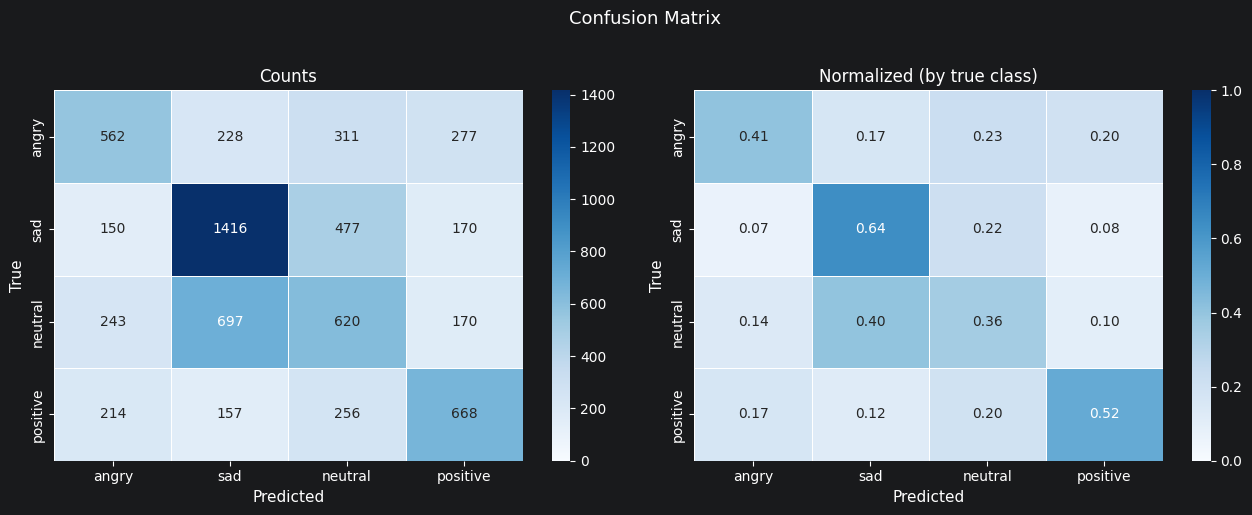

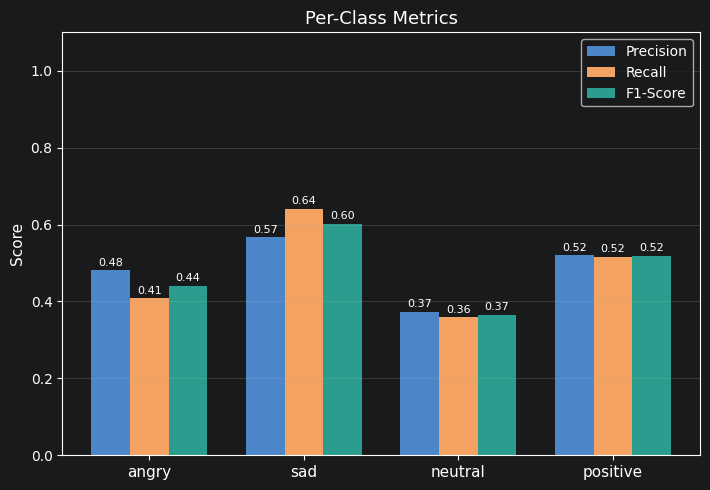

In [10]:
import joblib

model_xgb_path = CHECKPOINTS_DIR / 'openSmile_XGBoost_combine_balanced_train_model.pkl'
model_xgb = joblib.load(model_xgb_path)
print(f'XGBoost model loaded: {model_xgb_path}')
print(f'Model type: {type(model_xgb).__name__}')

X_test_xgb, y_test_xgb = load_features_for_sklearn(TEST_LMDB)

y_pred_xgb_str = model_xgb.predict(X_test_xgb)
probs_xgb = model_xgb.predict_proba(X_test_xgb) if hasattr(model_xgb, 'predict_proba') else None

y_true_xgb = np.array([parse_label_to_index(l) for l in y_test_xgb])
y_pred_xgb = np.array([parse_label_to_index(l) for l in y_pred_xgb_str])

metrics_xgb = compute_classification_metrics(y_true_xgb, y_pred_xgb, probs_xgb)
print_eval_block('OpenSmile XGBoost - Test Metrics', metrics_xgb, y_true_xgb, y_pred_xgb)

---
## 5. CNN

**Тип:** Свёрточная нейронная сеть  
**Архитектура:** 3× Conv2D → AdaptiveAvgPool → Linear  
**Признаки:** Спектрограмма (из LMDB ключ 'x')  
**Чекпоинт:** `CNN_combine_balanced_train_model.pt`

✓ Checkpoint загружен из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/CNN_combine_balanced_train_model.pt

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CNN - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Accuracy,0.5707
1,Balanced Accuracy,0.5573
2,F1 (macro),0.5638
3,F1 (weighted),0.5737
4,Precision (macro),0.5831
5,Recall (macro),0.5573
6,Wa,0.5573
7,ROC-AUC (OvR macro),0.8190
8,Loss,1.0532


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.5896,0.5370,0.5621,1378
1,sad,0.6904,0.6358,0.6620,2213
2,neutral,0.4402,0.5994,0.5076,1730
3,positive,0.6122,0.4571,0.5234,1295


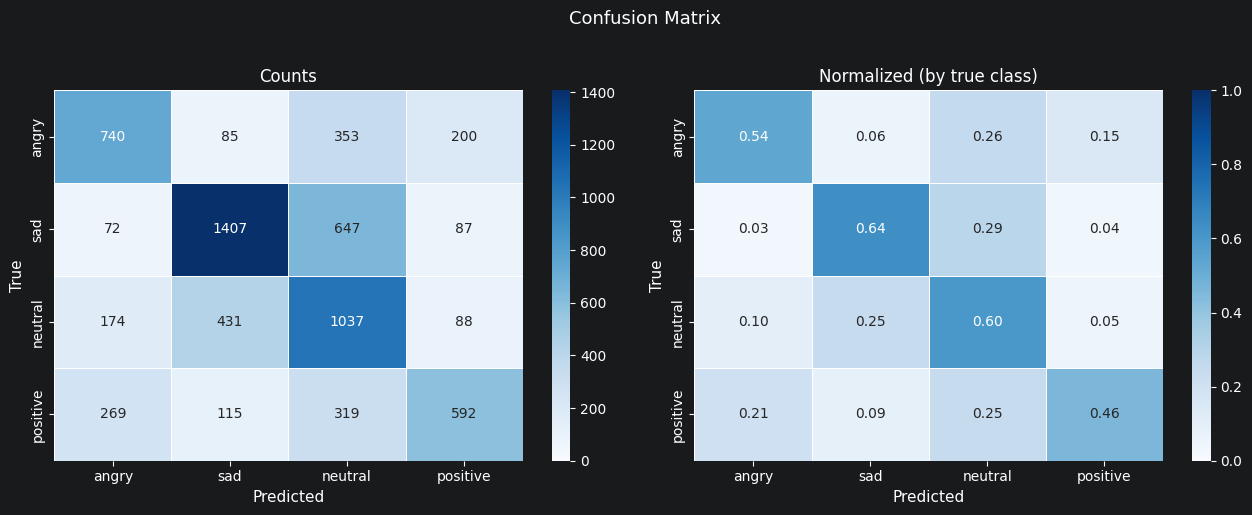

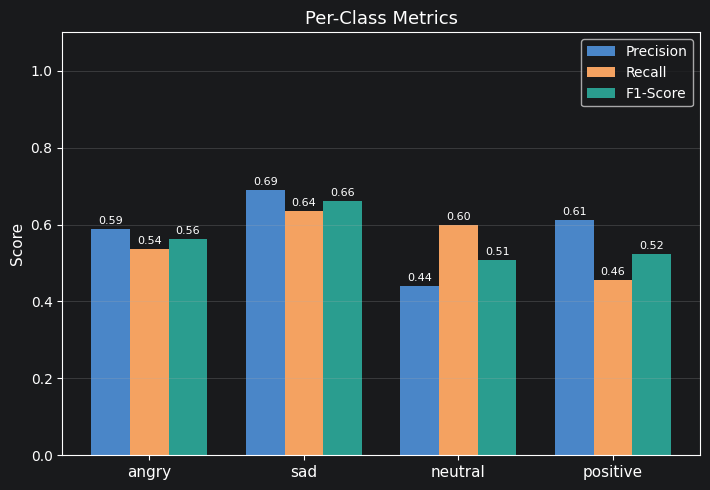

In [11]:
from torch import nn
from torch.utils.data import DataLoader
from dusha.my_experiments.audio_models.CNN.CNN import EmotionCNN, LmdbFeaturesDataset, pad_collate_fn, evaluate_split

checkpoint_cnn = load_pytorch_model(
    'combine_balanced_train', models_dir=CHECKPOINTS_DIR, model_name='CNN', map_location=DEVICE
)
model_cnn = EmotionCNN(n_classes=4)
model_cnn.load_state_dict(checkpoint_cnn['model_state_dict'])
model_cnn.to(DEVICE)
model_cnn.eval()

test_ds_cnn = LmdbFeaturesDataset(TEST_LMDB)
test_loader_cnn = DataLoader(test_ds_cnn, batch_size=32, shuffle=False, collate_fn=pad_collate_fn, num_workers=0)
criterion = nn.CrossEntropyLoss()

metrics_cnn, yt_cnn, yp_cnn, probs_cnn, _ = evaluate_split(model_cnn, test_loader_cnn, criterion, DEVICE)
print_eval_block('CNN - Test Metrics', metrics_cnn, yt_cnn, yp_cnn)

---
## 6. CNN + BiLSTM

**Тип:** Свёрточная + рекуррентная нейронная сеть  
**Архитектура:** 3× Conv2D → BiLSTM → Linear  
**Признаки:** Спектрограмма (из LMDB ключ 'x')  
**Чекпоинт:** `CNN_BiLSTM_combine_balanced_train_model.pt`

✓ Checkpoint загружен из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/CNN_BiLSTM_combine_balanced_train_model.pt

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CNN+BiLSTM - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Accuracy,0.7396
1,Balanced Accuracy,0.7304
2,F1 (macro),0.7317
3,F1 (weighted),0.7382
4,Precision (macro),0.7347
5,Recall (macro),0.7304
6,Wa,0.7304
7,ROC-AUC (OvR macro),0.9207
8,Loss,0.7090
9,Uar,0.7304


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.7498,0.7874,0.7681,1378
1,sad,0.7920,0.8292,0.8102,2213
2,neutral,0.6635,0.6509,0.6571,1730
3,positive,0.7333,0.6541,0.6914,1295


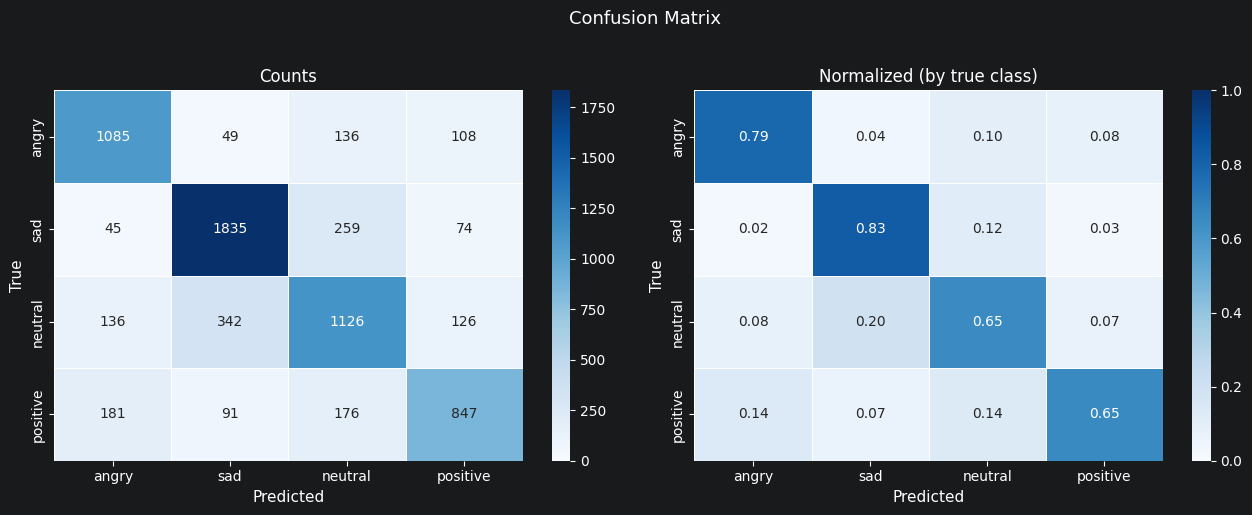

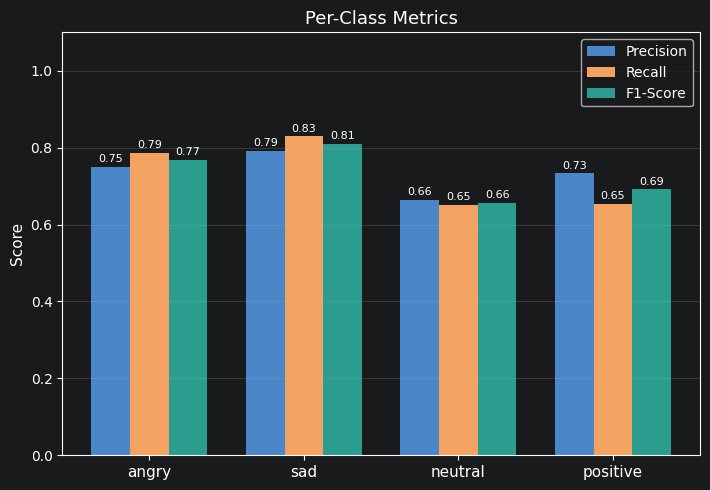

In [12]:
from dusha.my_experiments.audio_models.CNN.CNN_BiLSTM import EmotionCNNBiLSTM, evaluate_split, pad_collate_fn as pad_collate_bilstm, LmdbFeaturesDataset

checkpoint_cnnbilstm = load_pytorch_model(
    'combine_balanced_train', models_dir=CHECKPOINTS_DIR, model_name='CNN_BiLSTM', map_location=DEVICE
)
model_cnnbilstm = EmotionCNNBiLSTM(n_classes=4)
model_cnnbilstm.load_state_dict(checkpoint_cnnbilstm['model_state_dict'])
model_cnnbilstm.to(DEVICE)
model_cnnbilstm.eval()

test_ds_cb = LmdbFeaturesDataset(TEST_LMDB)
test_loader_cb = DataLoader(test_ds_cb, batch_size=32, shuffle=False, collate_fn=pad_collate_bilstm, num_workers=0)
criterion = nn.CrossEntropyLoss()

metrics_cb, yt_cb, yp_cb, probs_cb, _ = evaluate_split(model_cnnbilstm, test_loader_cb, criterion, DEVICE)
print_eval_block('CNN+BiLSTM - Test Metrics', metrics_cb, yt_cb, yp_cb)

---
## 7. wav2vec2 XLSR-300M + Self-Attention

**Тип:** Предобученный трансформер (Wav2Vec2-XLSR-300M) + Attention Pooling  
**Признаки:** Raw waveform (из LMDB ключ 'waveform')  
**Чекпоинт:** `wav2vec2_xlsr300m_self_attention_combine_balanced_train_small_best.ckpt`  
**Примечание:** Требует доступа к HuggingFace для загрузки Wav2Vec2-модели.

Loaded checkpoint: /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/wav2vec2_xlsr300m_self_attention_combine_balanced_train_small_best.ckpt
Checkpoint keys: ['model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'scaler_state_dict', 'epoch', 'global_step', 'best_f1']
Running on CPU — expect ~30-60 min for 6616 samples.
Evaluation took 5894s

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Wav2Vec2 XLSR-300M + Self-Attention - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Accuracy,0.6443
1,Balanced Accuracy,0.6525
2,F1 (macro),0.6484
3,F1 (weighted),0.6488
4,Precision (macro),0.6643
5,Recall (macro),0.6525
6,Wa,0.6525
7,ROC-AUC (OvR macro),0.8758
8,Loss,0.8587


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.6684,0.7431,0.7038,1378
1,sad,0.8363,0.5748,0.6813,2213
2,neutral,0.4994,0.6757,0.5743,1730
3,positive,0.6530,0.6162,0.6341,1295


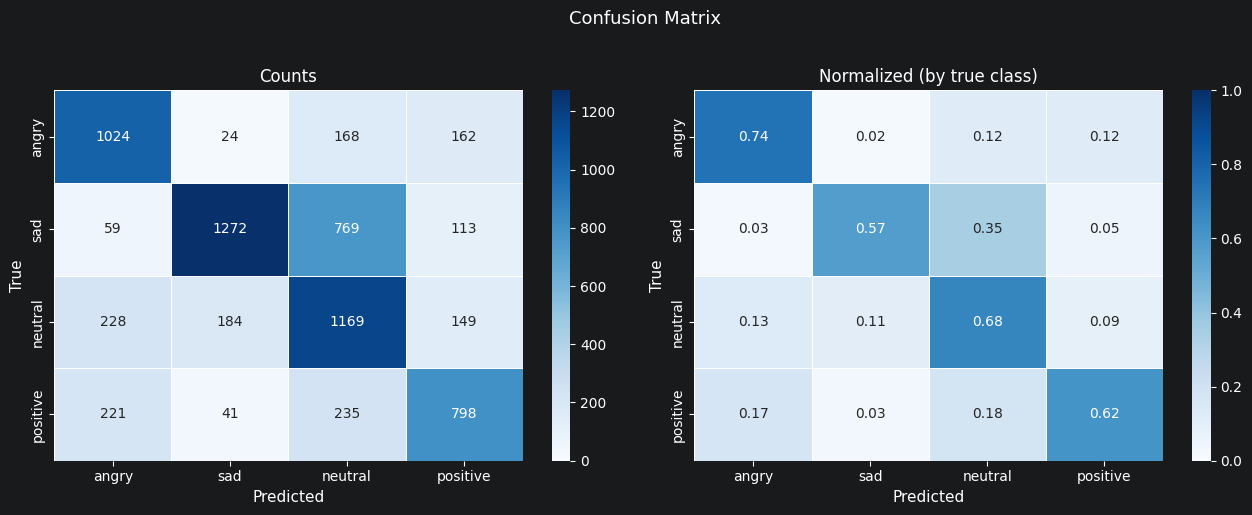

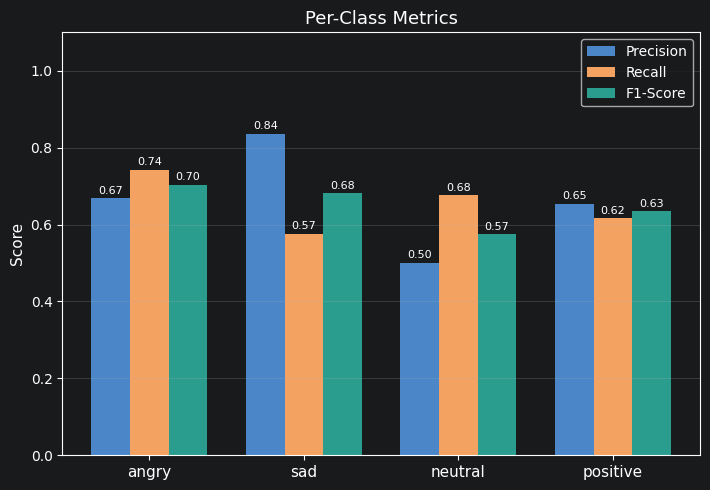

In [13]:
import torch
import time
from torch import nn
from torch.utils.data import DataLoader
from dusha.my_experiments.audio_models.transformers.wav2vec_self_attention import (
    Wav2VecSelfAttentionClassifier, LmdbWaveDataset, wave_collate_fn, evaluate_split as wav2vec_evaluate_split,
)

device_obj = torch.device(DEVICE)

ckpt_path = CHECKPOINTS_DIR / 'wav2vec2_xlsr300m_self_attention_combine_balanced_train_small_best.ckpt'
checkpoint_w2v = torch.load(ckpt_path, map_location=device_obj, weights_only=False)
print(f'Loaded checkpoint: {ckpt_path}')
print(f'Checkpoint keys: {list(checkpoint_w2v.keys())}')

model_w2v = Wav2VecSelfAttentionClassifier(
    pretrained_name='facebook/wav2vec2-xls-r-300m',
    n_classes=4,
    pooling_type='mean',
)
model_w2v.load_state_dict(checkpoint_w2v['model_state_dict'])
model_w2v.to(device_obj)
model_w2v.eval()

test_ds_w2v = LmdbWaveDataset(TEST_LMDB, is_train=False, min_crop_sec=5.0, max_crop_sec=6.0)
test_loader_w2v = DataLoader(test_ds_w2v, batch_size=8, shuffle=False, collate_fn=wave_collate_fn, num_workers=0)
criterion = nn.CrossEntropyLoss()

if device_obj.type == 'cpu':
    _t0 = time.time()
    print(f'Running on CPU — expect ~30-60 min for {len(test_ds_w2v)} samples.')

metrics_w2v, yt_w2v, yp_w2v, probs_w2v, _ = wav2vec_evaluate_split(
    model_w2v, test_loader_w2v, criterion, device_obj, use_amp=False
)

if device_obj.type == 'cpu':
    print(f'Evaluation took {time.time() - _t0:.0f}s')

print_eval_block('Wav2Vec2 XLSR-300M + Self-Attention - Test Metrics', metrics_w2v, yt_w2v, yp_w2v)